<a href="https://www.kaggle.com/code/sonawanelalitsunil/hearing-wellness-2025-ml-47-44?scriptVersionId=256391212" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/2025-hearing-wellness-survey/Hearing well-being Survey Report.csv


## Title:
Hearing Wellness 2025

## Description:
The 2025 Hearing Wellness Survey is designed to understand awareness, habits, and challenges related to hearing health in today’s world. It explores factors such as exposure to noise, use of hearing protection devices, lifestyle influences, and access to regular hearing checkups. The survey also seeks insights into how individuals perceive hearing wellness, the impact of technology and headphones on auditory health, and common barriers to seeking professional care. The findings will help identify trends, raise awareness, and support initiatives aimed at promoting better hearing practices and early prevention strategies.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/2025-hearing-wellness-survey/Hearing well-being Survey Report.csv")

In [3]:
df.head()

,Perceived_Hearing_Meaning,Hearing_FOMO,Hearing_Test_Barrier,Missed_Important_Sounds,Left_Out_Due_To_Hearing,Daily_Headphone_Use,Belief_Early_Hearing_Care,Last_Hearing_Test_Method,Interest_in_Hearing_App,Desired_App_Features,Awareness_on_hearing_and_Willingness_to_invest,Paid_App_Test_Interest,Age_group,Ear_Discomfort_After_Use
0,"Staying independent and alert, Enjoying music,...",Sometimes,Cost,"Yes, in family conversations","Yes, often",My parent(s),5,"Self - application, Loved one, AI Support",Yes,"Privacy, Soft guidance, Visuals, Report sharin...",Yes,"Maybe, if it offers good value",18 - 24,No
1,"Staying independent and alert, Staying connect...",Rarely,Never felt the need,"Yes, in public spaces (trains, shops, announce...",Only in noisy places,My child/children,5,Self - application,Yes,Privacy,Yes,"No, I prefer getting tested at a hospital",18 - 24,Yes
2,"Staying independent and alert, I havenâ€™t tho...",Rarely,Shame,"Yes, during important work or school meetings",Sometimes,My parent(s),5,Self - application,Maybe,Soft guidance,No,"Yes, definitely",18 - 24,Maybe
3,Staying independent and alert,Yes often,Lack of awareness,"Yes, during important work or school meetings",Sometimes,1-2 hours,4,I've never taken a hearing test,"Yes, that would be helpful",Game-based interaction,Yes,"Yes, definitely",18 - 24,Occasionally
4,Staying independent and alert,Never,Lack of awareness,"No, I usually hear things well",Only in noisy places,Less than 1 hour,5,I've never taken a hearing test,"No, I don't think it's necessary","Quick tests, Game-based interaction, Detailed ...",No,"No, I prefer getting tested at a hospital",25 - 34,No


In [4]:
df.tail()

,Perceived_Hearing_Meaning,Hearing_FOMO,Hearing_Test_Barrier,Missed_Important_Sounds,Left_Out_Due_To_Hearing,Daily_Headphone_Use,Belief_Early_Hearing_Care,Last_Hearing_Test_Method,Interest_in_Hearing_App,Desired_App_Features,Awareness_on_hearing_and_Willingness_to_invest,Paid_App_Test_Interest,Age_group,Ear_Discomfort_After_Use
382,I havenâ€™t thought about it much,Rarely,Never thought about it,"Yes, in public spaces (trains, shops, announce...",Only in noisy places,1-2 hours,3,I've never taken a hearing test,"Maybe, if it's easy to use","Quick tests, Earphone calibration, Regular tes...",Yes,"Maybe, if it offers good value",18 - 24,Occasionally
383,Staying independent and alert,Yes often,I frequently testing by every six months,"Yes, during important work or school meetings","Yes, often",1-2 hours,5,At a hospital or clinic,"No, I don't think it's necessary","Quick tests, Regular testing reminders, Soft g...",Yes,"No, I prefer getting tested at a hospital",45 - 54,Yes
384,"Enjoying music, laughter, and life",Sometimes,Lack of awareness,"Yes, during important work or school meetings",Only in noisy places,1-2 hours,5,I've never taken a hearing test,"Maybe, if it's easy to use","Quick tests, Regular testing reminders, Soft g...",No,"No, I prefer getting tested at a hospital",18 - 24,Occasionally
385,I havenâ€™t thought about it much,Never,Lack of awareness,"No, I usually hear things well",Never,Less than 1 hour,5,At a hospital or clinic,"Maybe, if it's easy to use",Doctor consultation,No,"No, I prefer getting tested at a hospital",35 - 44,No
386,"Enjoying music, laughter, and life",Sometimes,Lack of awareness,"No, I usually hear things well",Sometimes,2-4 hours,4,I've never taken a hearing test,"Yes, that would be helpful","Quick tests, Game-based interaction, Earphone ...",Yes,"Maybe, if it offers good value",18 - 24,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 14 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   Perceived_Hearing_Meaning                       387 non-null    object
 1   Hearing_FOMO                                    387 non-null    object
 2   Hearing_Test_Barrier                            385 non-null    object
 3   Missed_Important_Sounds                         387 non-null    object
 4   Left_Out_Due_To_Hearing                         387 non-null    object
 5   Daily_Headphone_Use                             387 non-null    object
 6   Belief_Early_Hearing_Care                       387 non-null    int64 
 7   Last_Hearing_Test_Method                        387 non-null    object
 8   Interest_in_Hearing_App                         387 non-null    object
 9   Desired_App_Features                            387 no

In [6]:
df.describe()

,Belief_Early_Hearing_Care
count,387.000000
mean,3.958656
std,1.266690
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [7]:
df.dtypes

Perceived_Hearing_Meaning                         object
Hearing_FOMO                                      object
Hearing_Test_Barrier                              object
Missed_Important_Sounds                           object
Left_Out_Due_To_Hearing                           object
Daily_Headphone_Use                               object
Belief_Early_Hearing_Care                          int64
Last_Hearing_Test_Method                          object
Interest_in_Hearing_App                           object
Desired_App_Features                              object
Awareness_on_hearing_and_Willingness_to_invest    object
Paid_App_Test_Interest                            object
Age_group                                         object
Ear_Discomfort_After_Use                          object
dtype: object

In [8]:
df.shape

(387, 14)

In [9]:
df.isnull().sum()

Perceived_Hearing_Meaning                         0
Hearing_FOMO                                      0
Hearing_Test_Barrier                              2
Missed_Important_Sounds                           0
Left_Out_Due_To_Hearing                           0
Daily_Headphone_Use                               0
Belief_Early_Hearing_Care                         0
Last_Hearing_Test_Method                          0
Interest_in_Hearing_App                           0
Desired_App_Features                              0
Awareness_on_hearing_and_Willingness_to_invest    0
Paid_App_Test_Interest                            0
Age_group                                         0
Ear_Discomfort_After_Use                          0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['Perceived_Hearing_Meaning', 'Hearing_FOMO', 'Hearing_Test_Barrier',
       'Missed_Important_Sounds', 'Left_Out_Due_To_Hearing',
       'Daily_Headphone_Use', 'Belief_Early_Hearing_Care',
       'Last_Hearing_Test_Method', 'Interest_in_Hearing_App',
       'Desired_App_Features',
       'Awareness_on_hearing_and_Willingness_to_invest',
       'Paid_App_Test_Interest', 'Age_group', 'Ear_Discomfort_After_Use'],
      dtype='object')

## Data visualizations

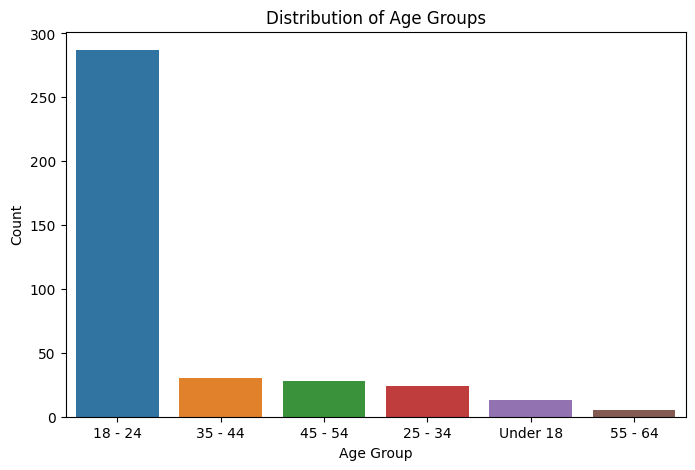

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Age_group", order=df["Age_group"].value_counts().index)
plt.title("Distribution of Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()


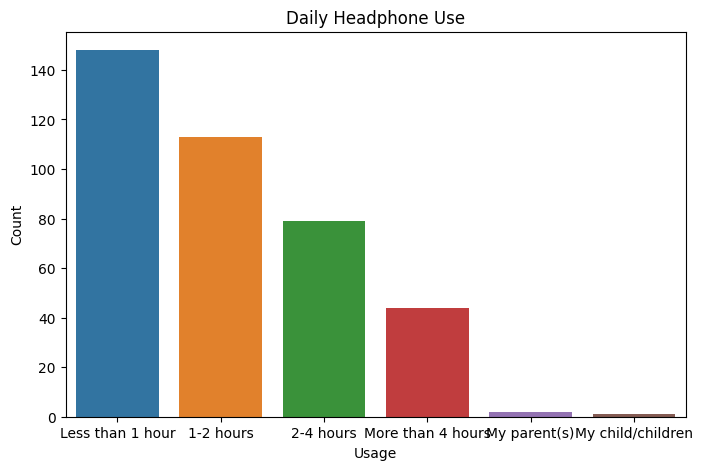

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Daily_Headphone_Use", order=df["Daily_Headphone_Use"].value_counts().index)
plt.title("Daily Headphone Use")
plt.xlabel("Usage")
plt.ylabel("Count")
plt.show()

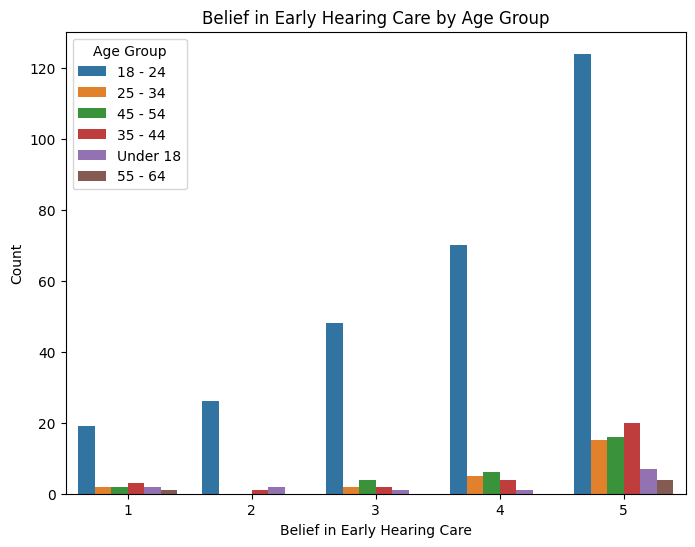

In [14]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="Belief_Early_Hearing_Care", hue="Age_group")
plt.title("Belief in Early Hearing Care by Age Group")
plt.xlabel("Belief in Early Hearing Care")
plt.ylabel("Count")
plt.legend(title="Age Group")
plt.show()

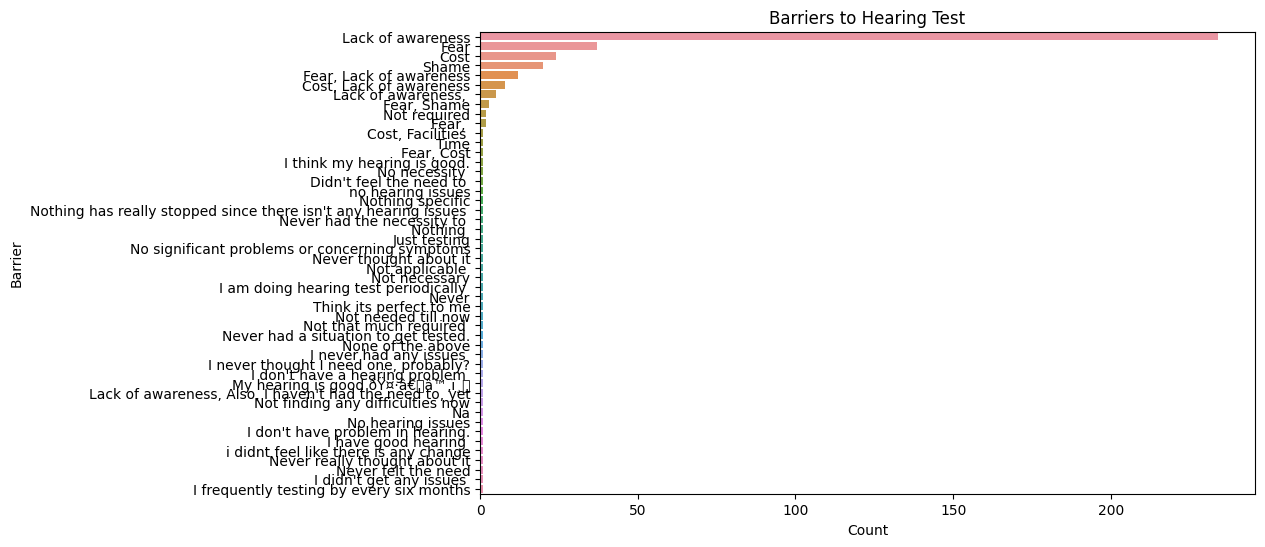

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y="Hearing_Test_Barrier", order=df["Hearing_Test_Barrier"].value_counts().index)
plt.title("Barriers to Hearing Test")
plt.xlabel("Count")
plt.ylabel("Barrier")
plt.show()


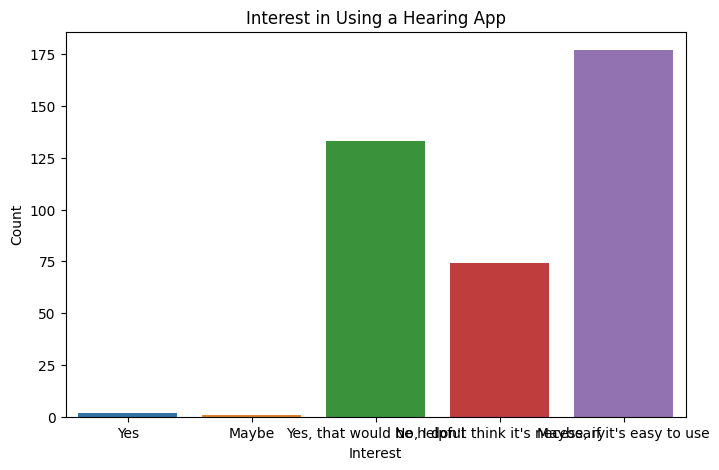

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Interest_in_Hearing_App")
plt.title("Interest in Using a Hearing App")
plt.xlabel("Interest")
plt.ylabel("Count")
plt.show()

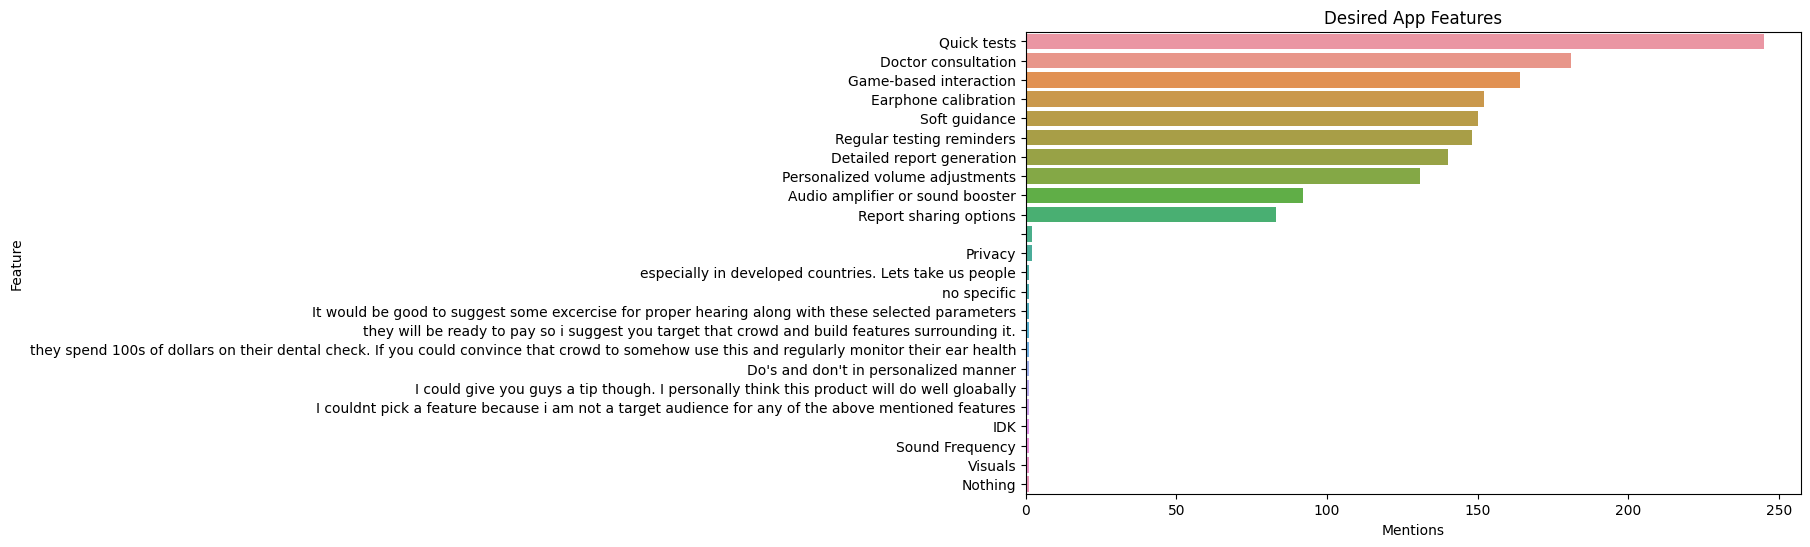

In [17]:
from collections import Counter

# Split features if multiple are listed (assuming comma separated)
features = df["Desired_App_Features"].dropna().str.split(",")
all_features = [f.strip() for sublist in features for f in sublist]
feature_counts = Counter(all_features)

feature_df = pd.DataFrame(feature_counts.items(), columns=["Feature", "Count"]).sort_values(by="Count", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_df, y="Feature", x="Count")
plt.title("Desired App Features")
plt.xlabel("Mentions")
plt.ylabel("Feature")
plt.show()


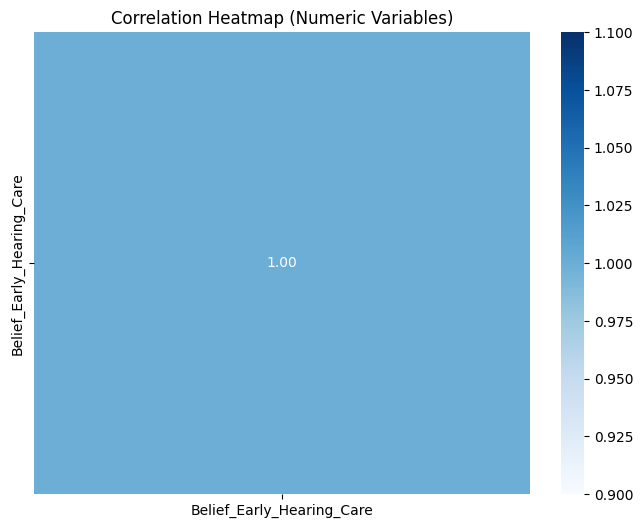

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Variables)")
plt.show()

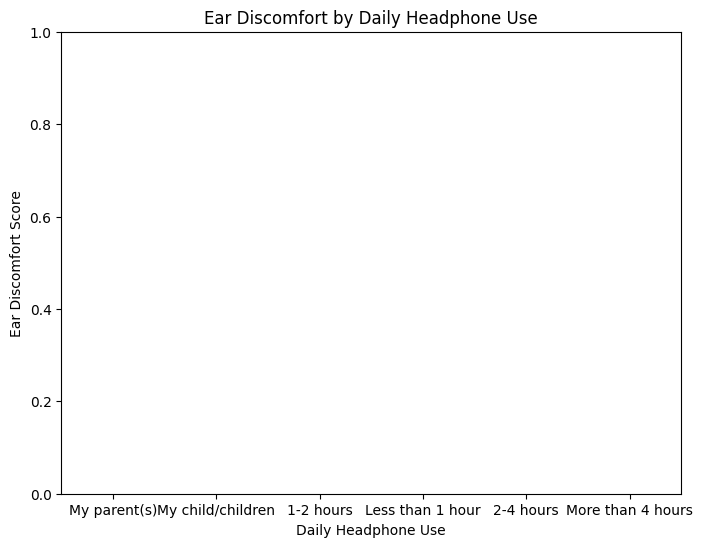

In [19]:
df["Ear_Discomfort_After_Use"] = pd.to_numeric(df["Ear_Discomfort_After_Use"], errors="coerce")

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="Daily_Headphone_Use", y="Ear_Discomfort_After_Use")
plt.title("Ear Discomfort by Daily Headphone Use")
plt.xlabel("Daily Headphone Use")
plt.ylabel("Ear Discomfort Score")
plt.show()

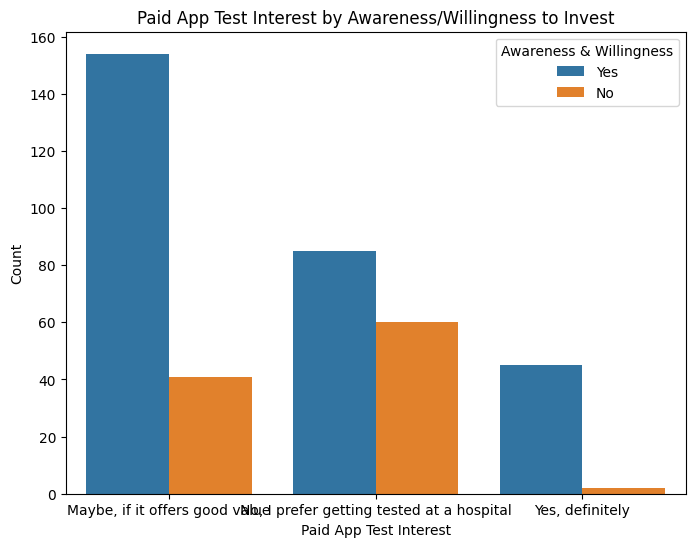

In [20]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="Paid_App_Test_Interest", hue="Awareness_on_hearing_and_Willingness_to_invest")
plt.title("Paid App Test Interest by Awareness/Willingness to Invest")
plt.xlabel("Paid App Test Interest")
plt.ylabel("Count")
plt.legend(title="Awareness & Willingness")
plt.show()

## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [22]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col].astype(str))

In [23]:
from sklearn.impute import SimpleImputer

# Drop columns with all NaN
df = df.dropna(axis=1, how="all")

# Apply imputer again
imputer = SimpleImputer(strategy="most_frequent")
df[:] = imputer.fit_transform(df)


In [24]:
target_col = "Interest_in_Hearing_App"   # change if you want another target
X = df.drop(target_col, axis=1)
y = df[target_col]


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracies[name] = round(acc, 2)

In [27]:
print("Model Accuracies (%):")
for model, acc in accuracies.items():
    print(f"{model}: {acc}%")

Model Accuracies (%):
Logistic Regression: 46.15%
Decision Tree: 41.03%
Random Forest: 41.03%
Naive Bayes: 47.44%
Support Vector Machine: 35.9%
K-Nearest Neighbors: 35.9%


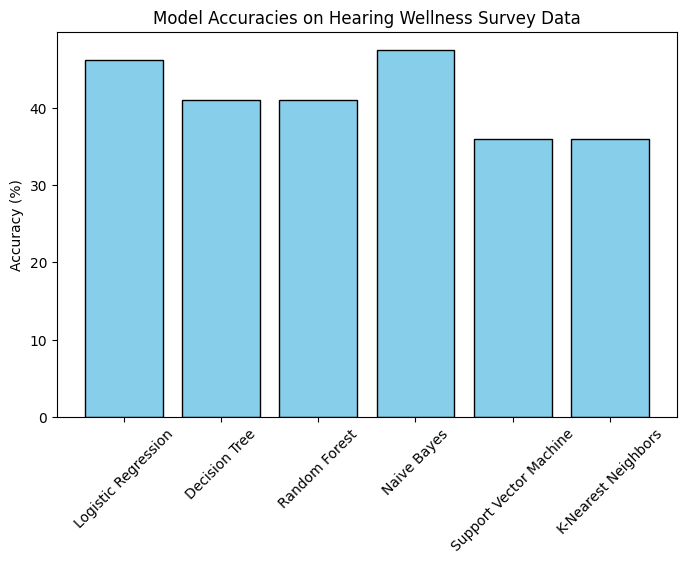

In [28]:
plt.figure(figsize=(8,5))
plt.bar(accuracies.keys(), accuracies.values(), color="skyblue", edgecolor="black")
plt.xticks(rotation=45)
plt.title("Model Accuracies on Hearing Wellness Survey Data")
plt.ylabel("Accuracy (%)")
plt.show()

## Thank you..pls upvote!!!